# 01 — Groundwater Transport (GWT) Model

This notebook adds a MODFLOW 6 **Groundwater Transport (GWT)** model to the simulation
built in `00_gwf.ipynb`. It simulates the migration of **Acid Mine Drainage (AMD)**
leaking from a tailings storage facility (TSF) into the aquifer.

> **Pre-requisite:** Run `00_gwf.ipynb` first so that the GWF model files exist in `model/`.

---

## Where is the TSF?

The TSF is placed **northeast of the pit**, on the upgradient (eastern) side.

With natural flow from east to west, AMD migrates:
1. **Period 1 (dewatering):** the cone of depression accelerates AMD toward the pit;
   dewatering wells partially capture the plume.
2. **Period 2 (recovery):** pumping stops, the plume resumes westward migration past
   the MAR zone and, over decades, reaches the GDE.

---

## What is a GWT model?

The GWT model solves the **advection-dispersion equation** for solute transport:

$$\frac{\partial (\theta C)}{\partial t} = \nabla \cdot (\theta \mathbf{D} \nabla C) - \nabla \cdot (\mathbf{q} C) + q_s C_s$$

where $C$ is concentration, $\theta$ is porosity, $\mathbf{D}$ is the dispersion tensor,
$\mathbf{q}$ is the Darcy flux (from GWF), and $q_s C_s$ is the source/sink term.

The GWT model is **coupled to GWF** — it reads the computed heads and flows from the GWF
model every time step and uses them to drive transport. The two models share the same TDIS
and spatial grid.

## Imports

In [13]:
import os
import numpy as np
import flopy
import pyemu
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from herebedragons import specify_tsf_cells, plot_setup

## Transport parameters

These are the only new parameters needed beyond what was defined in `00_gwf.ipynb`.

- **Porosity (θ = 0.3):** effective porosity — the fraction of the aquifer volume
  actually available to flowing water. Determines the pore-water velocity:
  $v = q / \theta$, so lower porosity → faster solute travel.
- **Longitudinal dispersivity (αL = 10 m):** spreading in the flow direction due to
  aquifer heterogeneity. A rule of thumb is αL ≈ 0.1 × travel distance, so 10 m is
  appropriate for a 100 m scale problem.
- **Transverse dispersivity (αT = 1 m):** lateral spreading perpendicular to flow;
  typically 1/10 of αL.
- **TSF concentration (C = 1.0):** normalised AMD tracer. Think of 1.0 as the peak
  concentration leaking from the tailings (e.g. 1000 mg/L sulfate); background = 0.

In [14]:
ws = 'model'

# AMD tracer
conc_amd = 1.0    # normalised concentration at TSF source (dimensionless)
conc_bg  = 0.0    # background concentration

# Aquifer transport properties
porosity = 0.30   # effective porosity
alpha_L  = 10.0   # longitudinal dispersivity (m)
alpha_T  = 1.0    # transverse dispersivity (m)

# TSF footprint — northeast of pit (col 65, row 30 ± a few cells)
tsf_col    = 65   # column index of TSF centre
tsf_row    = 30   # row index of TSF centre
tsf_half_c = 2    # half-width in columns → 5 cells × 20 m = 100 m
tsf_half_r = 1    # half-height in rows  → 3 cells × 20 m = 60 m

## Load the GWF simulation

We load the simulation written by `00_gwf.ipynb` so the GWT model can be added to the
same `MFSimulation` object. This means both models share the same TDIS (time
discretization) and are solved together in one MODFLOW 6 run.

`pitcells` are re-derived from the `idomain = 2` zone that `specify_pit_cells` tagged
in the GWF model — no need to rebuild the geometry from scratch.

In [15]:
sim = flopy.mf6.MFSimulation.load(sim_ws=ws)
gwf = sim.get_model()

# Re-derive pit cells from the idomain zone tag
pitcells = np.argwhere(gwf.dis.idomain.array[0] == 2)

nlay = gwf.dis.nlay.get_data()
nrow = gwf.dis.nrow.get_data()
ncol = gwf.dis.ncol.get_data()

loading simulation...
  loading simulation name file...
  loading tdis package...
  loading model gwf6...
    loading package dis...
    loading package npf...
    loading package sto...
    loading package ic...
    loading package oc...
    loading package rch...
    loading package ghb...
    loading package wel...
    loading package wel...
    loading package drn...
    loading package obs...
  loading solution package gwf...


## Update GWF output control

The GWT model needs the GWF cell-by-cell budget file (`.cbb`) to compute advective
fluxes and source/sink mass fluxes. We add `budget_filerecord` to the existing GWF
output control package before re-writing the simulation.

In [16]:
flopy.mf6.ModflowGwfoc(
    gwf,
    head_filerecord=f'{gwf.name}.hds',
    budget_filerecord=f'{gwf.name}.cbb',
    saverecord=[('HEAD', 'ALL'), ('BUDGET', 'ALL')],
    printrecord=[('BUDGET', 'ALL')],
)

package_name = oc
filename = gwf.oc
package_type = oc
model_or_simulation_package = model
model_name = gwf

Block options
--------------------
budget_filerecord
{internal}
(rec.array([('gwf.cbb',)],
          dtype=[('budgetfile', 'O')]))

head_filerecord
{internal}
(rec.array([('gwf.hds',)],
          dtype=[('headfile', 'O')]))


Block period
--------------------
saverecord
{internal}
(rec.array([('HEAD', 'ALL', None), ('BUDGET', 'ALL', None)],
          dtype=[('rtype', 'O'), ('ocsetting', 'O'), ('ocsetting_data', 'O')]))

printrecord
{internal}
(rec.array([('BUDGET', 'ALL', None)],
          dtype=[('rtype', 'O'), ('ocsetting', 'O'), ('ocsetting_data', 'O')]))



## GWT model object

`ModflowGwt` creates the transport model container inside the existing simulation.
By using the same `sim` object as GWF, MODFLOW 6 will automatically couple them
via the GWF6-GWT6 exchange added at the end of this notebook.

In [17]:
gwt = flopy.mf6.ModflowGwt(sim, modelname='gwt')

## GWT solver (IMS)

The transport equation is linear (concentration does not affect flow), so a separate,
lighter IMS is registered for GWT. `SIMPLE` complexity with tighter convergence
criteria (`1×10⁻⁶`) is appropriate — transport matrices are better conditioned than
the nonlinear GWF matrices.

In [18]:
ims_gwt = flopy.mf6.ModflowIms(
    sim,
    pname='ims_gwt',
    complexity='SIMPLE',
    linear_acceleration='BICGSTAB',
    outer_maximum=100,
    outer_dvclose=1e-6,
    inner_maximum=50,
    inner_dvclose=1e-6,
)
sim.register_ims_package(ims_gwt, [gwt.name])

## Grid (DIS)

GWT requires its own DIS package, but the grid must be identical to GWF's.
We read the arrays directly from the loaded GWF model rather than re-specifying them.

In [19]:
dis_gwt = flopy.mf6.ModflowGwtdis(
    gwt,
    nlay=nlay, nrow=nrow, ncol=ncol,
    delr=gwf.dis.delr.get_data(),
    delc=gwf.dis.delc.get_data(),
    top=gwf.dis.top.get_data(),
    botm=gwf.dis.botm.get_data(),
    idomain=gwf.dis.idomain.get_data(),
    length_units='meters',
)

## Initial conditions (IC)

All cells start with zero AMD concentration — the aquifer is clean before mining begins.

In [20]:
ic_gwt = flopy.mf6.ModflowGwtic(gwt, strt=conc_bg)

## Mobile storage and transfer (MST)

MST defines how much solute is stored per unit volume of aquifer. The key parameter
is **porosity** — the fraction of volume occupied by water where solute resides.

Porosity controls the **pore-water velocity**: $v = q/\theta$. With $\theta = 0.3$
and a Darcy flux of $q = K \cdot i = 5 \times 0.005 = 0.025$ m/day, the average
pore-water velocity is ~0.08 m/day → AMD travels ~30 m/year under natural gradient.

In [21]:
mst = flopy.mf6.ModflowGwtmst(gwt, porosity=porosity)

## Advection (ADV)

ADV moves solute with the groundwater flow field computed by GWF.

`scheme='TVD'` (Total Variation Diminishing) is a higher-order scheme that reduces
numerical oscillations near sharp concentration fronts — important here because the
TSF injects a step-change in concentration. The simpler `'UPSTREAM'` scheme is
faster but produces more numerical diffusion (artificially smears the plume front).

In [22]:
adv = flopy.mf6.ModflowGwtadv(gwt, scheme='UTVD')

## Dispersion (DSP)

DSP spreads the plume beyond pure advection due to:
- **Mechanical dispersion** — solute travels at different speeds through different pore
  paths (fast through large pores, slow through small ones). Scales with velocity:
  $D_L = \alpha_L \cdot v$, $D_T = \alpha_T \cdot v$.
- **Molecular diffusion** (`diffc`) — Brownian motion of solute molecules. Minor at
  groundwater velocities; set to 0 here for simplicity.

The dispersion tensor gives the plume an elongated shape: longer in the flow direction
(longitudinal) and shorter transversely. With αL/αT = 10:1, the plume will be
approximately 10× longer east–west than it is wide north–south.

In [23]:
dsp = flopy.mf6.ModflowGwtdsp(
    gwt,
    xt3d_off=True,   # use standard finite-difference dispersion
    diffc=0.0,       # molecular diffusion (m²/day)
    alh=alpha_L,     # longitudinal dispersivity (m)
    ath1=alpha_T,    # transverse dispersivity (m)
)

## Source/sink mixing (SSM)

SSM tells MODFLOW what concentration to assign to water entering the aquifer through
boundary conditions:

- **Sinks** (dewatering wells, drain): remove solute at the local aquifer concentration.
- **Sources** (GHB inflow, recharge, MAR wells): inject water at a specified concentration.

With `sources=[]` all sources inject **clean water at C = 0**, which is physically
reasonable: regional inflow is uncontaminated, rain is clean, and MAR injects treated
water. This means MAR actively **dilutes** the AMD plume — you can test the dilution
effect by comparing runs with and without MAR.

In [24]:
ssm = flopy.mf6.ModflowGwtssm(gwt)

## Tailings source — Constant Concentration (CNC)

CNC fixes the concentration at specified cells to a constant value for the duration
of a stress period. It is the transport equivalent of a constant-head boundary in GWF.

The TSF footprint is a **5 × 3 cell rectangle (100 m × 60 m)** centred northeast of
the pit. The concentration is held at `conc_amd = 1.0` during periods 1 and 2
(throughout mining and into recovery), representing continuous leaching from the
tailings pile.

> **Try it:** set `conc_amd = 0` in period 2 (`stress_period_data={1: tsf_cells}`) to
> simulate a TSF that is capped and stops leaching when mining ends.

In [25]:
tsf_cells = specify_tsf_cells(
    col_center=tsf_col, row_center=tsf_row,
    half_ncol=tsf_half_c, half_nrow=tsf_half_r,
    conc=conc_amd,
)
print(f"TSF footprint: {len(tsf_cells)} cells "
      f"({(2*tsf_half_c+1)*20} m × {(2*tsf_half_r+1)*20} m)")

cnc = flopy.mf6.ModflowGwtcnc(
    gwt,
    stress_period_data={1: tsf_cells, 2: tsf_cells},
)

TSF footprint: 15 cells (100 m × 60 m)


## Output control (OC)

Save the concentration array to a binary `.ucn` file every time step.
This is read by flopy's `HeadFile` utility (with `text='CONCENTRATION'`) for
post-processing — same interface as reading heads from a `.hds` file.

In [26]:
oc_gwt = flopy.mf6.ModflowGwtoc(
    gwt,
    concentration_filerecord=f'{gwt.name}.ucn',
    saverecord=[('CONCENTRATION', 'ALL')],
    printrecord=[('BUDGET', 'ALL')],
)

## GWF–GWT exchange

The `GWF6-GWT6` exchange registers the coupling between the two models in the
simulation's name file. At each time step MODFLOW:
1. Solves GWF → computes heads and cell-by-cell flows.
2. Passes those flows to GWT.
3. Solves GWT → computes concentrations driven by the GWF flow field.

This is a **one-way coupling**: flow drives transport, but transport does not feed back
into flow (concentration does not change density or viscosity here). For density-driven
flow (e.g. saltwater intrusion) you would need a fully coupled GWF-GWT solve.

In [27]:
gwfgwt = flopy.mf6.ModflowGwfgwt(
    sim,
    exgtype='GWF6-GWT6',
    exgmnamea=gwf.name,
    exgmnameb=gwt.name,
)

## Visualise model setup

Same map as `00_gwf.ipynb` but with the TSF footprint overlaid in blue.
Verify that the TSF sits northeast of the pit, upgradient of all other features.

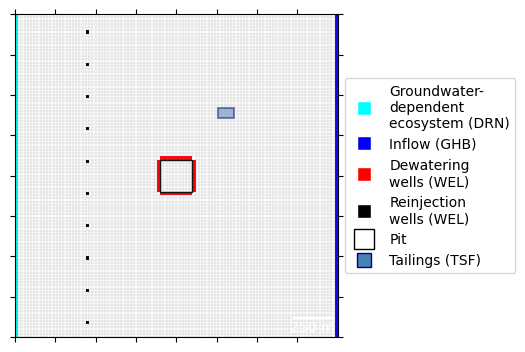

In [28]:
plot_setup(gwf, pitcells, tsf_cells=tsf_cells)

## Write and run

Re-writing the simulation updates the GWF name file (adds budget output) and
writes all GWT input files. MODFLOW 6 then solves GWF and GWT together.

In [29]:
sim.write_simulation()
pyemu.os_utils.run('mf6', cwd=ws)

writing simulation...
  writing simulation name file...
  writing simulation tdis package...
  writing solution package gwf...
  writing solution package ims_gwt...
  writing package modflowsim.gwfgwt...
  writing model gwf...
    writing model name file...
    writing package dis...
    writing package npf...
    writing package sto...
    writing package ic...
    writing package rcha_0...
    writing package ghb-inflow...
    writing package wel_ts...
    writing package wel_ts...
    writing package wel_ts...
    writing package wel_ts...
    writing package wel_ts...
    writing package wel_ts...
    writing package wel_ts...
    writing package wel_ts...
    writing package wel_ts...
    writing package wel_ts...
    writing package wel_ts...
    writing package wel_ts...
    writing package wel_ts...
    writing package wel_ts...
    writing package wel_ts...
    writing package wel_ts...
    writing package wel_ts...
    writing package wel_ts...
    writing package wel_ts...
 

# Visualize GWT model setup

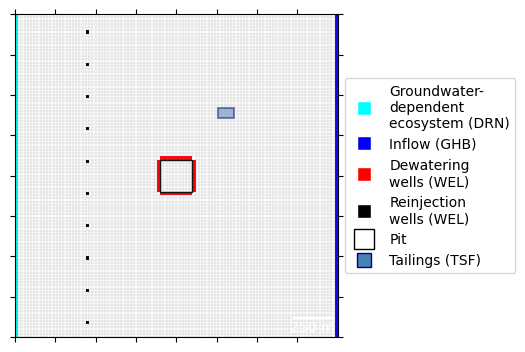

In [30]:
plot_setup(gwf, pitcells, tsf_cells=tsf_cells)

## Visualise the AMD plume

We read the concentration file and plot snapshots at three key moments:
- End of period 1 (dewatering off, t = 10 years) — plume under pumping capture
- Mid recovery (t = 50 years) — plume migrating west post-mining
- End of simulation (t = 110 years) — GDE impact?

The TSF is marked as a black square; the pit outline is shown for reference.

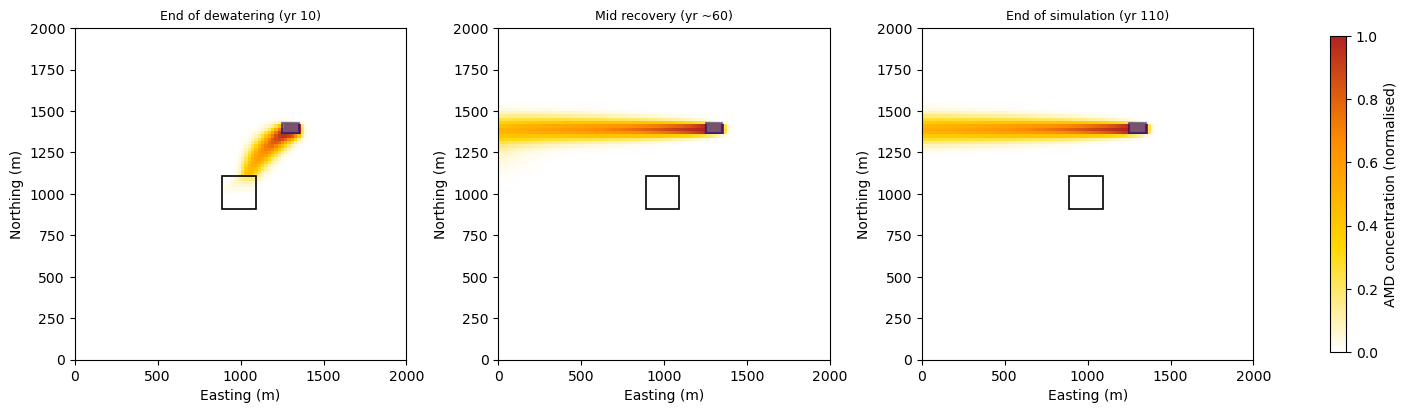

In [35]:
ucn_file = os.path.join(ws, f'{gwt.name}.ucn')
cobj = flopy.utils.HeadFile(ucn_file, text='CONCENTRATION')
kstpkper = np.array(cobj.get_kstpkper())   # shape (ntimes, 2): (kstp, kper)

# Pick snapshots: last step of period 1, midpoint and end of period 2
snap_labels = ['End of dewatering (yr 10)', 'Mid recovery (yr ~60)', 'End of simulation (yr 110)']
per1 = kstpkper[kstpkper[:, 1] == 1]
per2 = kstpkper[kstpkper[:, 1] == 2]
snaps = [
    tuple(per1[-1]),            # last step of period 1
    tuple(per2[len(per2)//2]),  # midpoint of period 2
    tuple(kstpkper[-1]),        # very last step
]

mg   = gwf.modelgrid
delr = gwf.dis.delr.get_data()[0]

fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
cmap = mcolors.LinearSegmentedColormap.from_list('amd', ['white', 'gold', 'darkorange', 'firebrick'])

for ax, ksp, label in zip(axes, snaps, snap_labels):
    conc = cobj.get_data(kstpkper=ksp)[0]   # shape (nrow, ncol)
    im = ax.imshow(conc, origin='upper', cmap=cmap, vmin=0, vmax=1,
                   extent=[0, mg.ncol * delr, 0, mg.nrow * delr])

    # Pit outline
    pit_rows, pit_cols = pitcells[:, 0], pitcells[:, 1]
    x0    = (pit_cols.min() - 0.5) * delr
    y0    = (mg.nrow - pit_rows.max() - 0.5) * delr
    pit_w = (pit_cols.max() - pit_cols.min() + 1) * delr
    pit_h = (pit_rows.max() - pit_rows.min() + 1) * delr
    ax.add_patch(plt.Rectangle((x0, y0), pit_w, pit_h, lw=1.2, edgecolor='k', facecolor='none'))

    # TSF outline
    tsf_x0 = (tsf_col - tsf_half_c - 0.5) * delr
    tsf_y0 = (mg.nrow - tsf_row - tsf_half_r - 0.5) * delr
    tsf_w  = (2 * tsf_half_c + 1) * delr
    tsf_h  = (2 * tsf_half_r + 1) * delr
    ax.add_patch(plt.Rectangle((tsf_x0, tsf_y0), tsf_w, tsf_h,
                                lw=1.5, edgecolor='navy', facecolor='steelblue', alpha=0.5))

    ax.set_title(label, fontsize=9)
    ax.set_xlabel('Easting (m)')
    ax.set_ylabel('Northing (m)')

fig.colorbar(im, ax=axes, label='AMD concentration (normalised)', shrink=0.9)
plt.show()